In [1]:
import os
import csv
import cantera as ct
import numpy as np
import rmgpy.chemkin
import rmgpy.tools.plot
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
mech_yaml = '/home/moon/uncertainty_estimator/BM_covariances/propane_20260513/cantera_from_ck/chem_annotated.yaml'
gas = ct.Solution(mech_yaml)
sensitivity = np.load('sensitivities.npy')
concs = np.load('concentrations.npy')
temperatures = np.load('temperatures.npy')

In [3]:
def get_i_thing(ref_composition, phase):
    """Helper function for getting the index of a species in a Cantera phase given its composition"""
    for i in range(phase.n_species):
        if phase.species()[i].composition == ref_composition:
            return i
    assert False, f"Could not find species with composition {ref_composition} in phase {phase.name}"

In [4]:
concs.shape
mole_fracs = concs

In [5]:
# convert to mass fractions

concs2 = np.load('../conc_20260518.npy')
mass_fracs = np.load('../mass_fracs_20260518.npy')
# concs2 = np.load('../conc_20260518.npy')


In [6]:
np.isclose(concs, concs2).all()

True

Text(0, 0.5, 'Concentration')

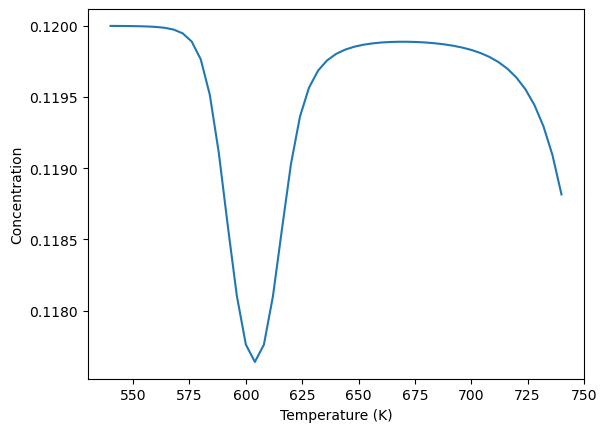

In [7]:
i_sp = get_i_thing({'C': 3, 'H': 8}, gas)
# i_sp = get_i_thing({'C': 2, 'H': 4}, gas)

plt.plot(temperatures, concs[:, i_sp])
plt.xlabel('Temperature (K)')
plt.ylabel('Concentration')

Text(0, 0.5, 'Sensitivity')

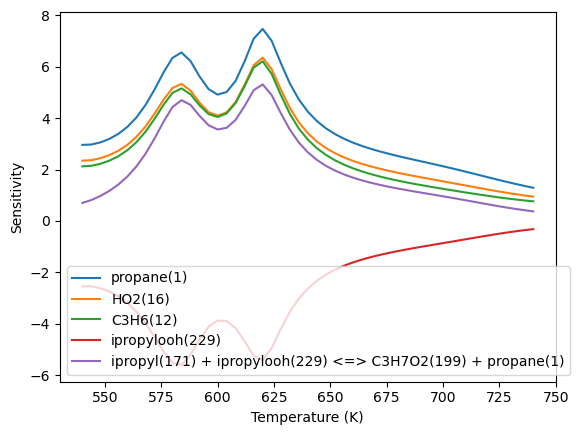

In [8]:
i_sp = get_i_thing({'C': 3, 'H': 8}, gas)
i_sp = get_i_thing({'C': 2, 'H': 4}, gas)

top_N = 5
sens_sp = i_sp

max_conc = np.max(np.abs(sensitivity[:, :, sens_sp]), axis=0)
indices = np.arange(sensitivity.shape[1])
sorted_order = [x for _, x in sorted(zip(max_conc, indices))][::-1]
for i in range(top_N):
    j = sorted_order[i]
    if j > gas.n_reactions:
        label = gas.species_names[j - gas.n_reactions]
    else:
        label = gas.reaction_equations()[j]
    plt.plot(temperatures, sensitivity[:, j, sens_sp], label=label)

plt.legend()
# plt.plot(temperatures, sensitivity[:, gas.n_reactions + i_sp, i_sp], )
# plt.plot(temperatures, sensitivity[:, gas.n_reactions + i_sp +1, i_sp])
plt.xlabel('Temperature (K)')
plt.ylabel('Sensitivity')

# Convert from Cantera's mass-based sensitivity to mole-based sensitivity

In [9]:
molecular_weights = gas.molecular_weights / 1000.0  # convert from kg/kmol to kg/mol
mol_sensitivities = np.zeros_like(sensitivity) + np.nan

for i in range(sensitivity.shape[1]):  # repeat over perturbed parameter p
    for k in range(sensitivity.shape[2]):  # repeat over sensitive species concentration y_k
        
        sum_xj_Wj = np.zeros(sensitivity.shape[0])
        for j in range(gas.n_species):
            sum_xj_Wj += mass_fracs[:, j] / molecular_weights[j]

        low_d_high = np.multiply(np.multiply(sum_xj_Wj, mass_fracs[:, k]), sensitivity[:, i, k] / molecular_weights[k])

        sum_xj_Winv_dx_dp = np.zeros(sensitivity.shape[0])
        for j in range(gas.n_species):
            sum_xj_Winv_dx_dp += np.multiply(mass_fracs[:, j], sensitivity[:, i, j] / molecular_weights[j])
        high_d_low = np.multiply(sum_xj_Winv_dx_dp, mass_fracs[:, k] / molecular_weights[k])

        mol_sensitivities[:, i, k] = np.divide(np.divide((low_d_high - high_d_low), np.float_power(sum_xj_Wj, 2.0)), mole_fracs[:, k])

/tmp/ipykernel_263769/3188644442.py:18: RuntimeWarning: divide by zero encountered in divide
  mol_sensitivities[:, i, k] = np.divide(np.divide((low_d_high - high_d_low), np.float_power(sum_xj_Wj, 2.0)), mole_fracs[:, k])
/tmp/ipykernel_263769/3188644442.py:18: RuntimeWarning: invalid value encountered in divide
  mol_sensitivities[:, i, k] = np.divide(np.divide((low_d_high - high_d_low), np.float_power(sum_xj_Wj, 2.0)), mole_fracs[:, k])


### Plot again

Text(0, 0.5, 'Sensitivity')

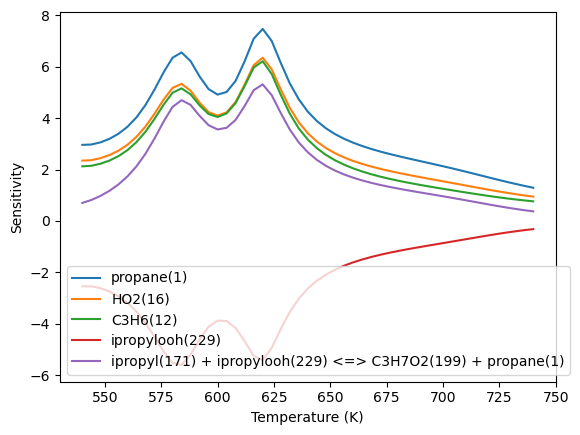

In [10]:
i_sp = get_i_thing({'C': 3, 'H': 8}, gas)
i_sp = get_i_thing({'C': 2, 'H': 4}, gas)

top_N = 5
sens_sp = i_sp

max_conc = np.max(np.abs(mol_sensitivities[:, :, sens_sp]), axis=0)
indices = np.arange(mol_sensitivities.shape[1])
sorted_order = [x for _, x in sorted(zip(max_conc, indices))][::-1]
for i in range(top_N):
    j = sorted_order[i]
    if j > gas.n_reactions:
        label = gas.species_names[j - gas.n_reactions]
    else:
        label = gas.reaction_equations()[j]
    plt.plot(temperatures, mol_sensitivities[:, j, sens_sp], label=label)

plt.legend()
# plt.plot(temperatures, sensitivity[:, gas.n_reactions + i_sp, i_sp], )
# plt.plot(temperatures, sensitivity[:, gas.n_reactions + i_sp +1, i_sp])
plt.xlabel('Temperature (K)')
plt.ylabel('Sensitivity')

In [11]:

base_dir = '/home/moon/uncertainty_estimator/BM_covariances/propane_sensitivity/sens_csvs'


species_list, reaction_list = rmgpy.chemkin.load_chemkin_file(
    '/home/moon/uncertainty_estimator/BM_covariances/propane_20260513/chemkin/chem_annotated.inp',
    '/home/moon/uncertainty_estimator/BM_covariances/propane_20260513/chemkin/species_dictionary.txt'
)


# make a sensitivity worksheet for each species
sens_worksheet = []
for spec in species_list:
            csvfile_path = os.path.join(base_dir, 'solver',
                                        'sensitivity_{0}_SPC_{1}.csv'.format(1, spec.index))
            sens_worksheet.append(csvfile_path)
# Write sensitivities to CSV files, one file per sensitive species

sensitivity_threshold = 1e-12
for j in range(len(species_list)):
    with open(sens_worksheet[j], 'w') as outfile:
        species_name = species_list[j].to_chemkin()
        headers = ['Time (s)']

        worksheet = csv.writer(outfile)
        reactions_above_threshold = []  # includes species too
        for i in range(len(reaction_list) + len(species_list)):
            for t in range(len(sensitivity)):  # loop over time steps
                if abs(mol_sensitivities[t][i, j]) > sensitivity_threshold:
                    reactions_above_threshold.append(i)
                    break

        # need conversion from Cantera to RMG and back
        headers.extend([f'dln[{species_name}]/dln[k{i + 1}]: {reaction_list[i].to_chemkin(kinetics=False)}' if i < len(reaction_list)
                        else f'dln[{species_name}]/dG[{species_list[i - len(reaction_list)].to_chemkin()}]' for i in reactions_above_threshold])

        worksheet.writerow(headers)
        for t in range(len(temperatures)):
            row = [temperatures[t]]
            row.extend([mol_sensitivities[t][i, j] for i in reactions_above_threshold])
            worksheet.writerow(row)

INFO:root:Thermo file has default temperature range 300.0 to 1000.0 and 1000.0 to 5000.0
